In [1]:
import os
from pathlib import Path

from dotenv import load_dotenv

load_dotenv()

PROJECT_ROOT = Path(os.getenv("PROJECT_ROOT"))
print(PROJECT_ROOT)
print(PROJECT_ROOT.is_dir())


DATA_DIR = Path(os.getenv("DATA_DIR"))
print(DATA_DIR)
print(DATA_DIR.is_dir())

/home/dyretna/Dokument/Code/GitHub/nightingale_projects/ai_counterfactuals_tests
True
/home/dyretna/Dokument/Code/GitHub/nightingale_projects/ai_counterfactuals_tests/data
True


test on data with one target

In [2]:
TRAIN_DATA_PATH = DATA_DIR / "05_single_target" / "ess_ready_v2_hltprdi_train.csv"
print(TRAIN_DATA_PATH.is_file())

TEST_DATA_PATH = DATA_DIR / "05_single_target" / "ess_ready_v2_hltprdi_test.csv"
print(TEST_DATA_PATH.is_file())

True
True


In [3]:
import pandas as pd

train_df = pd.read_csv(TRAIN_DATA_PATH)
test_df = pd.read_csv(TEST_DATA_PATH)

In [4]:
train_df.head(3)

,etfruit,eatveg,cgtsmok,alcfreq,slprl,paccnois,bmi,gndr,health,dosprt,hltprdi
0,3.0,3.0,6.0,3.0,2.0,0,36.921078,1,3.0,0.0,0
1,2.0,3.0,6.0,4.0,1.0,0,22.386314,1,2.0,7.0,0
2,4.0,4.0,6.0,6.0,1.0,0,30.846277,2,3.0,1.0,0


In [5]:
print(train_df.shape)
print(test_df.shape)

(32883, 11)
(8221, 11)


The distribution on the classes for all three targets are as we can see very skewed.
below we can se that the distribution is the same on train and test data-files.

In [6]:
y = "hltprdi"
X = [c for c in train_df.columns if c not in y]

In [7]:
y_train = train_df[y]
X_train = train_df[X]

# Setup and training with gridsearch pipelines

In [8]:
from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.naive_bayes import GaussianNB, BernoulliNB, MultinomialNB, ComplementNB

In [20]:
import warnings
from sklearn.exceptions import ConvergenceWarning

toggle_warnings = True

if toggle_warnings:
    warnings.filterwarnings("ignore", category=UserWarning)
    warnings.filterwarnings("ignore", category=RuntimeWarning)
    warnings.filterwarnings("ignore", category=ConvergenceWarning)


In [10]:
def grid_search_loop(X, y, pipeline, param_grid):
    # perform gridsearch
    grid_search = GridSearchCV(pipeline,
                            param_grid=param_grid,
                            verbose=0,
                            n_jobs=-1,
    )
    grid_search.fit(X_train, y_train)

    print("\n", grid_search.best_estimator_)
    print(grid_search.best_params_)

    return grid_search.best_estimator_


In [11]:
pipeline = Pipeline( # we can also add encoders etc...
    [
        ("scaler", MinMaxScaler()),
        ("gaussianNB", GaussianNB())
    ]
)

param_grid = dict(
    scaler=[MinMaxScaler(), StandardScaler(), None], # we override scaler, add standard for testing...

    gaussianNB__priors=[
        None,              # let model calculate class balance
        [0.5, 0.5],        # even distribution on classes
        [0.7, 0.3],        # klass 0 more common
        [0.3, 0.7],        # klass 1 more common
    ],
    gaussianNB__var_smoothing=[0.1, 0.001, 1e-6, 1e-9, 1e-12],
)

# perform gridsearch
best_gaussianNB = grid_search_loop(
    X_train, y_train,
    pipeline, param_grid,
)


 Pipeline(steps=[('scaler', None),
                ('gaussianNB', GaussianNB(var_smoothing=0.1))])
{'gaussianNB__priors': None, 'gaussianNB__var_smoothing': 0.1, 'scaler': None}


In [13]:
pipeline = Pipeline(
    [
        ("scaler", MinMaxScaler()),
        ("bernoulliNB", BernoulliNB())
    ]
)
param_grid = dict(
    scaler=[MinMaxScaler(), StandardScaler(), None],

    bernoulliNB__alpha=[0.0, 0.5, 1.0, 2.0],
    bernoulliNB__force_alpha=[True, False],
    bernoulliNB__binarize=[None, 0.0, 0.5, 1.0],
    bernoulliNB__fit_prior=[True, False],
    bernoulliNB__class_prior=[
        None,
        [0.5, 0.5],
        [0.7, 0.3],
        [0.3, 0.7],
    ],
)
best_bernoulliNB = grid_search_loop(
    X_train, y_train,
    pipeline, param_grid,
)


 Pipeline(steps=[('scaler', MinMaxScaler()),
                ('bernoulliNB', BernoulliNB(alpha=0.0, binarize=None))])
{'bernoulliNB__alpha': 0.0, 'bernoulliNB__binarize': None, 'bernoulliNB__class_prior': None, 'bernoulliNB__fit_prior': True, 'bernoulliNB__force_alpha': True, 'scaler': MinMaxScaler()}


In [14]:
pipeline = Pipeline(
    [
        ("scaler", MinMaxScaler()),
        ("multinomialNB", MultinomialNB())
    ]
)

param_grid = dict(
    scaler=[MinMaxScaler(), StandardScaler(), None],

    multinomialNB__alpha=[0.0, 0.5, 1.0, 2.0],
    multinomialNB__fit_prior=[True, False],
    multinomialNB__class_prior=[
        None,
        [0.5, 0.5],
        [0.7, 0.3],
        [0.3, 0.7],
    ],
)

best_multinomialNB = grid_search_loop(
    X_train, y_train,
    pipeline, param_grid,
)


 Pipeline(steps=[('scaler', MinMaxScaler()),
                ('multinomialNB', MultinomialNB(alpha=0.0))])
{'multinomialNB__alpha': 0.0, 'multinomialNB__class_prior': None, 'multinomialNB__fit_prior': True, 'scaler': MinMaxScaler()}


In [15]:
pipeline = Pipeline(
    [
        ("scaler", MinMaxScaler()),
        ("complementNB", ComplementNB())
    ]
)

param_grid = dict(
    scaler=[MinMaxScaler(), StandardScaler(), None],

    complementNB__alpha=[0.0, 0.1, 0.5, 1.0, 2.0],
    complementNB__force_alpha=[True, False],
    complementNB__fit_prior=[True, False],
    complementNB__class_prior=[
        None,
        [0.5, 0.5],
        [0.7, 0.3],
        [0.3, 0.7],
    ],
    complementNB__norm=[False, True],
)

best_complementNB = grid_search_loop(
    X_train, y_train,
    pipeline, param_grid,
)



 Pipeline(steps=[('scaler', MinMaxScaler()),
                ('complementNB', ComplementNB(alpha=2.0, norm=True))])
{'complementNB__alpha': 2.0, 'complementNB__class_prior': None, 'complementNB__fit_prior': True, 'complementNB__force_alpha': True, 'complementNB__norm': True, 'scaler': MinMaxScaler()}


# predictions

In [16]:
y_test = test_df[y]
X_test = test_df[X]

### save model preds

In [17]:
best_gaussianNB_pred = best_gaussianNB.predict(X_test)
best_bernoulliNB_pred = best_bernoulliNB.predict(X_test)
best_multinomialNB_pred = best_multinomialNB.predict(X_test)
best_complementNB_pred = best_complementNB.predict(X_test)

NB_models = {
    "gaussianNB": best_gaussianNB,
    "bernoulliNB": best_bernoulliNB,
    "multinomialNB": best_multinomialNB,
    "complementNB": best_complementNB,
}

NB_preds = {
    "gaussianNB": best_gaussianNB_pred,
    "bernoulliNB": best_bernoulliNB_pred,
    "multinomialNB": best_multinomialNB_pred,
    "complementNB": best_complementNB_pred,
}


In [ ]:
from sklearn.metrics import classification_report, roc_auc_score

for model_name, prediction in NB_preds.items():
    print("="*25, f"{model_name}", "="*25)
    # print(model["preds"])
    print(classification_report(y_test, prediction))
    print("Roc Score auc score: ", roc_auc_score(y_test, prediction), "\n")


========================= gaussianNB =========================
              precision    recall  f1-score   support

           0       0.94      1.00      0.97      7683
           1       0.75      0.02      0.03       538

    accuracy                           0.94      8221
   macro avg       0.84      0.51      0.50      8221
weighted avg       0.92      0.94      0.91      8221

Roc Score auc score:  0.5081690760318126 

========================= bernoulliNB =========================
              precision    recall  f1-score   support

           0       0.93      1.00      0.97      7683
           1       0.00      0.00      0.00       538

    accuracy                           0.93      8221
   macro avg       0.47      0.50      0.48      8221
weighted avg       0.87      0.93      0.90      8221

Roc Score auc score:  0.5 

========================= multinomialNB =========================
              precision    recall  f1-score   support

           0       0.93    

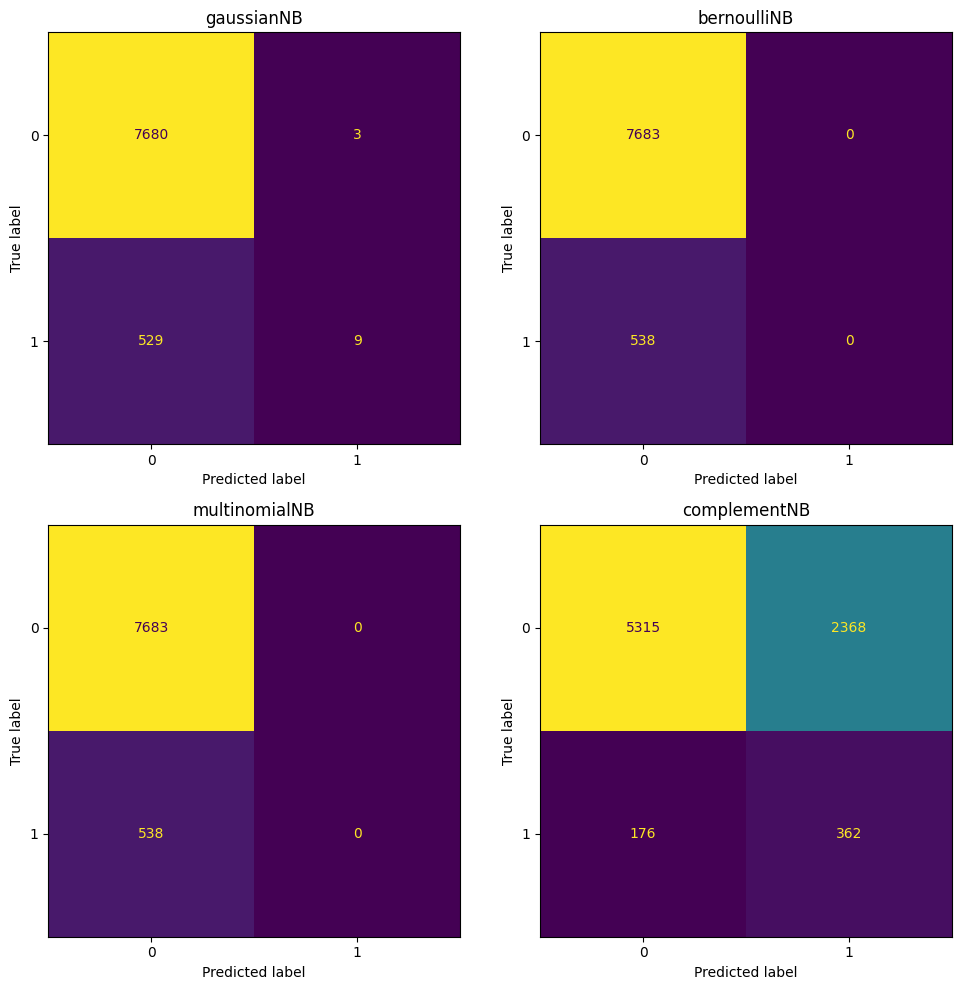

In [19]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix

fig, axes = plt.subplots(2, 2, figsize=(10, 10))

for ax, name in zip(axes.ravel(), NB_models.keys()):
    cm = confusion_matrix(y_test, NB_preds[name])
    ConfusionMatrixDisplay(cm).plot(ax=ax, colorbar=False)
    ax.set_title(name)

plt.tight_layout()
plt.show()


# Analysis

When training machine‑learning classifiers on imbalanced datasets, it is common to observe a systematic shift in error patterns depending on the choice of class weighting. In the unweighted case, models tend to minimize overall error by favoring the majority class, which typically results in high false‑negative rates for the minority class. This occurs because misclassifying minority‑class samples has little impact on the loss function when the majority class dominates the data distribution.

Applying class weights—such as class_weight="balanced" or class_weight="balanced_subsample"—alters the effective loss landscape by increasing the penalty for misclassifying minority‑class samples. The model is therefore encouraged to prioritize sensitivity (recall) for the minority class. A well‑known consequence of this reweighting is a shift in the decision boundary toward the minority class. As a result, the classifier becomes more likely to label ambiguous samples as belonging to the minority class. This reduces false negatives but simultaneously increases false positives.

This phenomenon is not specific to a particular algorithm. It appears across a wide range of models, including Random Forests, Complement Naive Bayes, and other probabilistic or ensemble methods. The underlying mechanism is the same: class weighting modifies the optimization objective so that the model trades precision for recall in the minority class. When the dataset is strongly imbalanced, this tradeoff becomes especially pronounced, and the model may converge to a region of the parameter space where improvements in recall necessarily come at the cost of increased false‑positive rates.